# Введення в PyTorch і персептрон

Персептрон є найпростішою формою нейронної мережі.

Нейронна мережа — утворення, що складається з вхідного шару (чутливі елементи, сенсори, S-елементи), 
вихідного шару (виконавчі, R-елементи) та певної кількості проміжних шарів (асоціативних, прихованих, A-елементів).

Кожен з елементів може знаходитись в одному з станів: активному чи неактивному (1 або 0). Активні елементи є джерелами сигналів для наступного шару, причому по різних зв'язках сигнал передається з різним коефіцієнтом (вагою зв'язку) — довільним дійсним числом. Навпаки, сигнали, що надходять до одного елементу за різними зв'язками, додаються (множені на коефіцієнти) та порівнюються з певним пороговим значенням, яке активує або деактивує відповідний елемент. Сукупність коефіцієнтів всієї мережі — визначає її роботу і є "знаннями" мережі.

Значення коефіцієнтів можуть бути кореговані в результаті навчання перцептрону:
- На вхід подаються тестові сигнали різних типів.
- Елементам, які активуються при цьому, змінюють вагу у відповідності до типу сигналу:
    - для сигналів одного типу — збільшують на 1
    - для сигналів іншого типу — зменшують на 1
 
Як результат будуть залишатись великі (за модулем) ваги лише для "різницевих" елементів, які активуються лише одним типом сигналів, а для тих, що активуються обома типами, сумарний результат буде близькій до нуля.  

Інший тип навчання - зворотнє поширення помилки. Якщо мережа дає неправильний результат, то різниця правильного та неправильного сигналу подається зворотнім шляхом і кожен коефіцієнт виправляється "градієнтом"

## Бізнес-контекст
Компанія HealthRisk Analytics будує прототип моделі, яка за простими показниками (наприклад, вік та індекс маси тіла) прогнозує рівень страхового ризику клієнта.
Ваше завдання — змоделювати основу цієї системи, використовуючи PyTorch: спочатку — один лінійний нейрон, потім — малу нейромережу.

## Завдання 1
Створіть тензори та виконайте базові операції.
- Уявіть, що кожен тензор — це стовпець даних про клієнтів (вік, вага, зріст).
- Створіть 1D, 2D і 3D тензори (torch.manual_seed(42)).
- Виконайте операції додавання і поелементного множення, щоб обчислити умовний показник ризику.
- Увімкніть requires_grad=True для одного тензора, перевірте наявність grad_fn.

In [1]:
import torch

In [2]:
torch.manual_seed(42)
age = torch.randint(18, 70, (5,), dtype=torch.float32)
age

tensor([36., 65., 50., 48., 48.])

In [3]:
age = torch.randn(5)
print("Початкові величини (нормлальний розподіл):)", age)
age = 44.0 + 26.0 * age
print("Після оброблення:", age)

Початкові величини (нормлальний розподіл):) tensor([ 0.3258, -0.8676,  1.5231,  0.6647, -1.0324])
Після оброблення: tensor([52.4695, 21.4417, 83.6015, 61.2813, 17.1564])


In [4]:
age_weight_height = torch.randn(5,3, requires_grad=True)
age_weight_height

tensor([[-0.2770, -0.1671, -0.1079],
        [-1.4285, -0.2810,  0.7489],
        [ 1.1164,  1.2931,  0.4137],
        [-0.5710, -0.9749,  0.1863],
        [ 1.6273,  1.1214, -0.6605]], requires_grad=True)

In [5]:
with torch.no_grad():
    age_weight_height[:,0] = 44.0 + 16.0 * age_weight_height[:,0]
    age_weight_height[:,1] = 95.0 + 25.0 * age_weight_height[:,1]  
    age_weight_height[:,2] = 180.0 + 15.0 * age_weight_height[:,2] 
age_weight_height

tensor([[ 39.5675,  90.8216, 178.3816],
        [ 21.1435,  87.9757, 191.2339],
        [ 61.8628, 127.3272, 186.2059],
        [ 34.8640,  70.6263, 182.7952],
        [ 70.0362, 123.0361, 170.0919]], requires_grad=True)

In [6]:
risk = age_weight_height[:,0] * age_weight_height[:,1]  + 0.5 * age_weight_height[:,2]
risk = (risk - risk.min()) / (risk.max() - risk.min())
risk

tensor([0.2560, 0.0000, 0.8915, 0.0886, 1.0000], grad_fn=<DivBackward0>)

## Завдання 2
Реалізуйте персептрон для передбачення ризику клієнта.
 * Згенеруйте дані (torch.randn, 100 зразків, 1 ознака — індекс маси тіла).
 * Цільова змінна — умовний "ризик" (лінійна комбінація + шум).
 * Побудуйте модель nn.Linear(1, 1) і функцію втрат MSE.
 * Виконайте 20 епох навчання з ручним оновленням параметрів.
 * Виведіть початкові та фінальні значення ваг і loss.



In [7]:
bmi = torch.randn(100,1)
print(bmi[:5])

noise = 0.1 * torch.randn(100, 1)
risk = 0.1 * bmi + noise
print(risk[:5])

tensor([[ 0.6872],
        [-1.0892],
        [-0.3553],
        [-0.9138],
        [-0.6581]])
tensor([[ 0.0916],
        [-0.1064],
        [-0.0701],
        [-0.0627],
        [-0.1389]])


In [8]:
import torch.nn as nn
import torch.optim as optim

class Perceptron(nn.Module) :
    def __init__(self) :
        super(Perceptron, self).__init__()
        self.layer1 = nn.Linear(1,1)
        self.activator = nn.Sigmoid()

    def forward(self, x) :
        x = self.layer1(x)
        x = self.activator(x)
        return x

loss_f = nn.functional.mse_loss

In [9]:
model = Perceptron()
learning_rate = 0.01

for epoch in range(20) : 
    output = model(bmi)
    loss = loss_f(output, risk)
    loss.backward()

    with torch.no_grad() :
        for param in model.parameters() :
            param -= learning_rate * param.grad
            param.grad.zero_()
        print(f"Epoch: {epoch}, loss: {loss.item():.4f}")

Epoch: 0, loss: 0.4059
Epoch: 1, loss: 0.4051
Epoch: 2, loss: 0.4042
Epoch: 3, loss: 0.4034
Epoch: 4, loss: 0.4026
Epoch: 5, loss: 0.4018
Epoch: 6, loss: 0.4009
Epoch: 7, loss: 0.4001
Epoch: 8, loss: 0.3993
Epoch: 9, loss: 0.3985
Epoch: 10, loss: 0.3976
Epoch: 11, loss: 0.3968
Epoch: 12, loss: 0.3960
Epoch: 13, loss: 0.3952
Epoch: 14, loss: 0.3944
Epoch: 15, loss: 0.3935
Epoch: 16, loss: 0.3927
Epoch: 17, loss: 0.3919
Epoch: 18, loss: 0.3911
Epoch: 19, loss: 0.3903


## Завдання 3
Навчіть той самий персептрон з оптимізатором SGD, щоб прискорити збіжність.
 * Налаштуйте torch.optim.SGD(lr = 0.01).
 * Виконайте 20 епох, фіксуючи loss.
 * Заповніть таблицю:

In [11]:
model2 = Perceptron()
bmi2 = torch.randn(100,1)
noise2 = 0.1 * torch.randn(100,1)
risk2 = 0.1 * bmi2 + noise2
losses2 = []
optimizer = optim.SGD(model2.parameters(), lr=0.01)
for epoch in range(20) : 
    output2 = model2(bmi2)
    loss = loss_f(output2, risk2)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    losses2.append(loss.item())
losses2

[0.23478111624717712,
 0.23425666987895966,
 0.23373298346996307,
 0.23321010172367096,
 0.2326880246400833,
 0.23216672241687775,
 0.23164623975753784,
 0.2311265915632248,
 0.23060771822929382,
 0.23008966445922852,
 0.22957241535186768,
 0.2290559709072113,
 0.22854037582874298,
 0.22802558541297913,
 0.22751162946224213,
 0.22699850797653198,
 0.2264862209558487,
 0.22597476840019226,
 0.22546415030956268,
 0.22495438158512115]

## Завдання 4
Побудуйте графік залежності втрат від епох і зробіть висновок:
 * Як швидко знижується помилка?
 * Який діапазон ваг забезпечує мінімальний ризик?
 * Збережіть графік у файл loss_healthrisk.png.







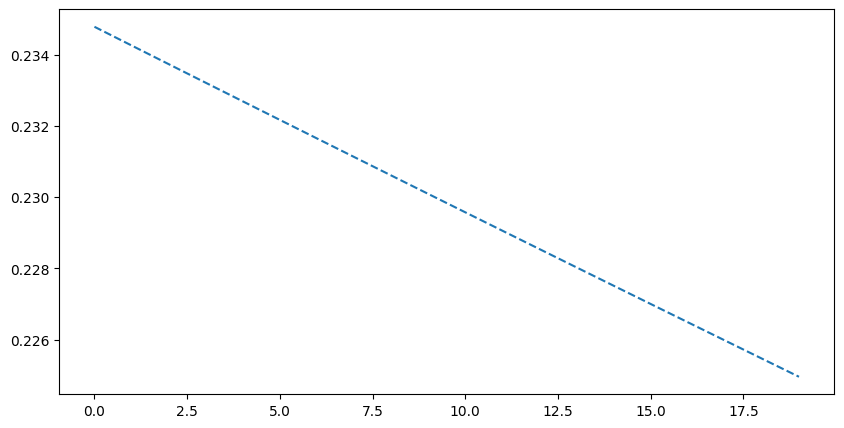

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot([i for i in range(20)], losses2, linestyle='--')

plt.show()

In [20]:
print("Втрати (помилка) зменшуються в середньому на {} за єпоху")
(losses2[19] - losses2[0]) / 20

Втрати (помилка) зменшуються в середньому на {} за єпоху


-0.0004913367331027985

In [ ]:
fig.savefig("loss_healthrisk.png")